# Breast Cancer Wisconsin Classification Workflow

This notebook walks through a complete binary classification workflow on the
Breast Cancer Wisconsin (Diagnostic) dataset using the reusable utilities in the
`cmor438_ml` package built for this CMOR 438 / INDE 577 final project.

**Goals**

- Demonstrate an end-to-end binary classification pipeline: load, explore,
  split, standardize, train, evaluate, and compare.
- Reuse the package utilities already implemented in `src/cmor438_ml` instead of
  rewriting logic inline, so the workflow stays short and reproducible.
- Compare two from-scratch classifiers, `KNNClassifier` and
  `LogisticRegressionGD`, on the same split.
- Keep every step readable and reproducible for the final project.

## 1. Project setup

We import the scientific Python stack (NumPy, pandas, matplotlib) and pull the
data, preprocessing, evaluation, and model utilities directly from the
`cmor438_ml` package. A fixed random seed keeps the split and any stochastic
steps reproducible across runs.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cmor438_ml import (
    load_breast_cancer_data,
    train_test_split,
    StandardScalerScratch,
    evaluate_classifier,
    compare_classifiers,
)
from cmor438_ml.models import KNNClassifier, LogisticRegressionGD

# Fixed seed for reproducibility wherever randomness is involved.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Load the dataset

The Breast Cancer Wisconsin (Diagnostic) dataset ships bundled with
scikit-learn, so `load_breast_cancer_data` reads it from the local installation
rather than downloading anything over the network.

We use two views of the same data:

- `return_frame=True` returns a tidy pandas `DataFrame` (features plus a
  `target` column) that is convenient for exploratory analysis.
- `return_frame=False` returns plain NumPy arrays (`X`, `y`) along with the
  feature and class names, which is what the models consume.

In this dataset the target encodes `0 = malignant` and `1 = benign`.

In [2]:
# Exploratory view as a DataFrame.
df = load_breast_cancer_data(return_frame=True)

# Modeling view as NumPy arrays plus the feature/class names.
X, y, feature_names, target_names = load_breast_cancer_data(return_frame=False)

print(f"DataFrame shape: {df.shape}")
print(f"Feature matrix X shape: {X.shape}")
print(f"Target vector y shape: {y.shape}")
print(f"Number of features: {len(feature_names)}")
print(f"Class names (index = label): {list(target_names)}")

DataFrame shape: (569, 31)
Feature matrix X shape: (569, 30)
Target vector y shape: (569,)
Number of features: 30
Class names (index = label): [np.str_('malignant'), np.str_('benign')]


In [3]:
# First few rows of the DataFrame.
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
# Target distribution: how many malignant (0) vs benign (1) samples.
target_counts = df["target"].value_counts().sort_index()
for label, count in target_counts.items():
    print(f"{label} ({target_names[label]}): {count}")

0 (malignant): 212
1 (benign): 357


## 3. Exploratory data analysis

Before modeling we look at a few summary statistics and visualize the class
balance and a couple of feature distributions. The two classes are reasonably
but not perfectly balanced, so accuracy alone is not the whole story — we will
also track precision, recall, and F1 later on. All plots use matplotlib only
(no seaborn), and figures are shown inline rather than saved to disk.

In [5]:
# Summary statistics for a few representative features.
selected_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean concavity",
]
df[selected_features].describe()

,mean radius,mean texture,mean perimeter,mean area,mean concavity
count,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.088799
std,3.524049,4.301036,24.298981,351.914129,0.079720
min,6.981000,9.710000,43.790000,143.500000,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.029560
50%,13.370000,18.840000,86.240000,551.100000,0.061540
75%,15.780000,21.800000,104.100000,782.700000,0.130700
max,28.110000,39.280000,188.500000,2501.000000,0.426800


In [6]:
# Class balance as proportions.
class_balance = df["target"].value_counts(normalize=True).sort_index()
for label, frac in class_balance.items():
    print(f"{label} ({target_names[label]}): {frac:.1%}")

0 (malignant): 37.3%
1 (benign): 62.7%


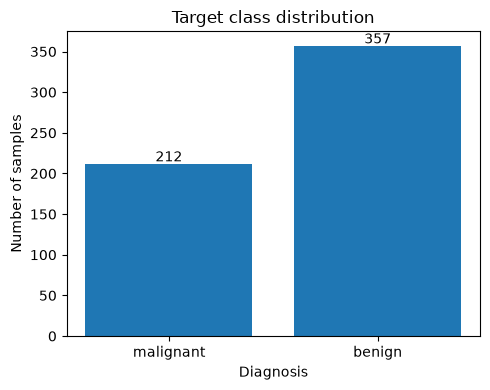

In [7]:
# Visualization 1: target class distribution as a bar chart.
counts = df["target"].value_counts().sort_index()
labels = [target_names[i] for i in counts.index]

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(labels, counts.values)
ax.set_title("Target class distribution")
ax.set_xlabel("Diagnosis")
ax.set_ylabel("Number of samples")
for i, value in enumerate(counts.values):
    ax.text(i, value + 3, str(value), ha="center")
plt.tight_layout()
plt.show()

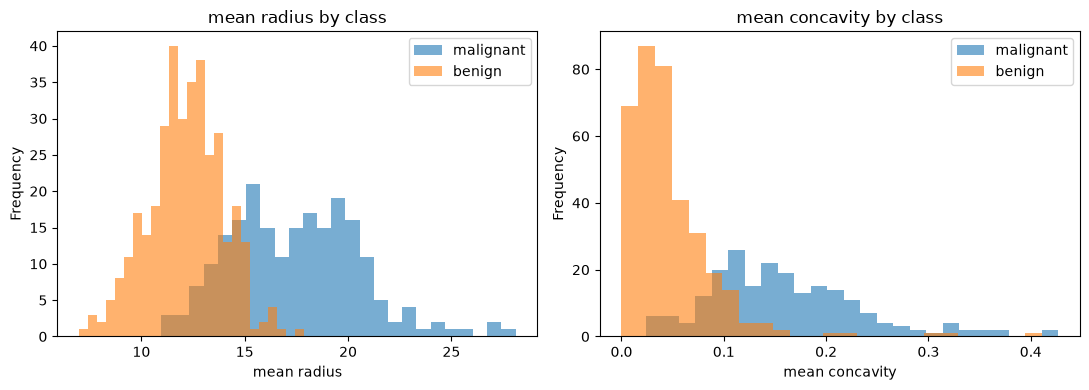

In [8]:
# Visualization 2: distribution of two informative features by class.
features_to_plot = ["mean radius", "mean concavity"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, feature in zip(axes, features_to_plot):
    for label in sorted(df["target"].unique()):
        subset = df.loc[df["target"] == label, feature]
        ax.hist(subset, bins=25, alpha=0.6, label=target_names[label])
    ax.set_title(f"{feature} by class")
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")
    ax.legend()
plt.tight_layout()
plt.show()

The histograms show that benign and malignant tumors separate fairly well along
features such as `mean radius` and `mean concavity`: malignant tumors tend
toward larger values. This overlap-but-separable structure is exactly the kind
of signal both classifiers can exploit.

## 4. Train/test split

We split the NumPy arrays into training and test partitions with the package's
`train_test_split`, holding out 25% of the data for testing and fixing
`random_state=42` for a reproducible split.

We split **before** any scaling. If we standardized using statistics computed
over the full dataset, information from the test set (its mean and spread) would
leak into the training pipeline and give an optimistically biased estimate of
performance. Splitting first keeps the test set a true held-out sample.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

X_train shape: (426, 30)
X_test shape:  (143, 30)
y_train shape: (426,)
y_test shape:  (143,)


## 5. Standardization

We fit `StandardScalerScratch` **only on the training features** and then apply
the learned mean and scale to both partitions. This mirrors the no-leakage
principle from the split: the scaler never sees the test data during fitting.

Standardization matters for both models here. KNN ranks neighbors by Euclidean
distance, so a feature measured on a large numeric scale (for example
`mean area`) would otherwise dominate the distance and drown out smaller-scale
features. Gradient-descent logistic regression converges much faster and more
stably when all features share a comparable scale, since the loss surface
becomes better conditioned.

In [10]:
scaler = StandardScalerScratch()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Sanity check: training features should now be roughly zero-mean, unit-variance.
print(f"Train mean (first 5 features): {np.round(X_train_scaled.mean(axis=0)[:5], 4)}")
print(f"Train std  (first 5 features): {np.round(X_train_scaled.std(axis=0)[:5], 4)}")

Train mean (first 5 features): [-0. -0. -0.  0. -0.]
Train std  (first 5 features): [1. 1. 1. 1. 1.]


## 6. Model training and evaluation

We train each classifier on the standardized training data and evaluate it with
`evaluate_classifier`, which fits the estimator and returns train accuracy plus
test accuracy, precision, recall, F1, and the test confusion matrix in a single
dictionary. The positive class defaults to label `1` (benign).

In [11]:
knn = KNNClassifier(n_neighbors=5)
logreg = LogisticRegressionGD(
    learning_rate=0.1,
    n_iterations=3000,
    fit_intercept=True,
    tolerance=1e-7,
)

knn_results = evaluate_classifier(
    knn, X_train_scaled, X_test_scaled, y_train, y_test
)
logreg_results = evaluate_classifier(
    logreg, X_train_scaled, X_test_scaled, y_train, y_test
)

In [12]:
def show_results(name, results):
    """Print the scalar metrics from an evaluate_classifier result dictionary."""
    print(f"== {name} ==")
    for key in [
        "train_accuracy",
        "test_accuracy",
        "test_precision",
        "test_recall",
        "test_f1",
    ]:
        print(f"  {key:<15}: {results[key]:.4f}")
    print()


show_results("KNN (k=5)", knn_results)
show_results("Logistic Regression GD", logreg_results)

== KNN (k=5) ==
  train_accuracy : 0.9718
  test_accuracy  : 0.9510
  test_precision : 0.9368
  test_recall    : 0.9889
  test_f1        : 0.9622

== Logistic Regression GD ==
  train_accuracy : 0.9930
  test_accuracy  : 0.9720
  test_precision : 0.9574
  test_recall    : 1.0000
  test_f1        : 0.9783



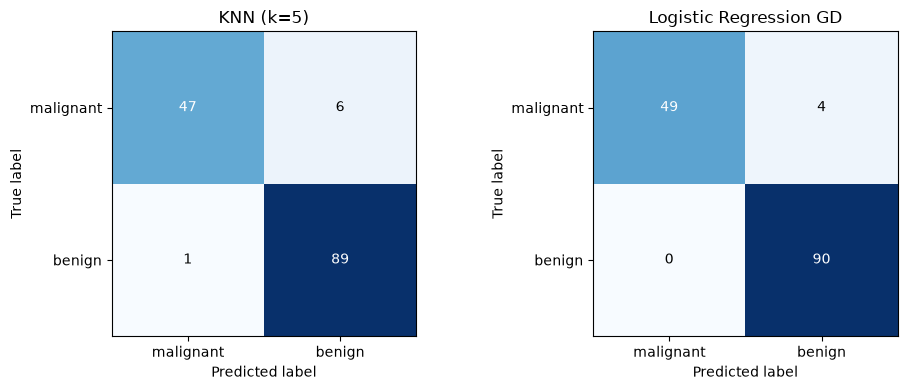

In [13]:
def plot_confusion_matrix(ax, matrix, title):
    """Render a 2x2 confusion matrix with labeled, annotated cells."""
    im = ax.imshow(matrix, cmap="Blues")
    ax.set_title(title)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(target_names)
    ax.set_yticklabels(target_names)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    threshold = matrix.max() / 2.0
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            text_color = "white" if matrix[i, j] > threshold else "black"
            ax.text(j, i, str(matrix[i, j]), ha="center", va="center", color=text_color)


fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_confusion_matrix(axes[0], knn_results["test_confusion_matrix"], "KNN (k=5)")
plot_confusion_matrix(
    axes[1], logreg_results["test_confusion_matrix"], "Logistic Regression GD"
)
plt.tight_layout()
plt.show()

## 7. Model comparison

`compare_classifiers` runs the same fit-and-score routine over a dictionary of
estimators and returns a tidy DataFrame, one row per model. A plain `dict`
preserves insertion order in Python 3.7+, so the rows appear in the order we
list the models.

In [14]:
models = {
    "KNN (k=5)": KNNClassifier(n_neighbors=5),
    "Logistic Regression GD": LogisticRegressionGD(
        learning_rate=0.1,
        n_iterations=3000,
        fit_intercept=True,
        tolerance=1e-7,
    ),
}

comparison = compare_classifiers(
    models, X_train_scaled, X_test_scaled, y_train, y_test
)
comparison

,model,train_accuracy,test_accuracy,test_precision,test_recall,test_f1
0,KNN (k=5),0.971831,0.951049,0.936842,0.988889,0.962162
1,Logistic Regression GD,0.992958,0.972028,0.957447,1.000000,0.978261


**Interpretation.** Reading across the table, `train_accuracy` shows how well
each model fits the data it learned from, while the `test_*` columns show how it
generalizes to unseen samples. A train accuracy close to the test accuracy
suggests the model is not badly overfitting. Precision (of the samples predicted
benign, how many truly are) and recall (of the truly benign samples, how many we
caught) together summarize the error trade-off, and F1 is their harmonic mean —
a useful single number when the classes are not perfectly balanced. In a medical
screening context the cost of a false negative differs from that of a false
positive, so it is worth reading precision and recall side by side rather than
collapsing everything into accuracy.

## 8. Brief hyperparameter check

As a small sensitivity check, we sweep the number of neighbors for KNN over
`k = 1, 3, 5, 9` while keeping the standardized features fixed, again using
`compare_classifiers` so the metrics are computed identically.

In [15]:
knn_variants = {
    f"KNN (k={k})": KNNClassifier(n_neighbors=k) for k in [1, 3, 5, 9]
}

knn_comparison = compare_classifiers(
    knn_variants, X_train_scaled, X_test_scaled, y_train, y_test
)
knn_comparison

,model,train_accuracy,test_accuracy,test_precision,test_recall,test_f1
0,KNN (k=1),1.000000,0.958042,0.956522,0.977778,0.967033
1,KNN (k=3),0.983568,0.965035,0.956989,0.988889,0.972678
2,KNN (k=5),0.971831,0.951049,0.936842,0.988889,0.962162
3,KNN (k=9),0.971831,0.937063,0.917526,0.988889,0.951872


**Interpretation.** With `k=1` the model memorizes the training set, so its
train accuracy is the highest while its test accuracy is not necessarily best;
increasing `k` smooths the decision boundary and trades a little training fit
for steadier generalization. Comparing the test columns across these values
shows how sensitive KNN is to the choice of `k` on this standardized dataset.

## 9. Conclusion

This notebook demonstrated a complete binary classification workflow on the
Breast Cancer Wisconsin dataset: loading the bundled data, exploring its class
balance and feature distributions, splitting before scaling to avoid leakage,
standardizing on the training set only, and then training, evaluating, and
comparing two from-scratch classifiers.

- **Which model did better.** The comparison table above reports the metrics for
  this particular train/test split; whichever model shows the higher test F1 and
  test accuracy is the stronger performer here. The confusion matrices show
  where the remaining errors fall.
- **Why reusable utilities help.** Loading, splitting, scaling, and scoring all
  go through shared `cmor438_ml` functions, so the same validated logic is
  applied everywhere. That keeps the notebook short, makes the steps easy to
  audit, and means re-running the notebook reproduces the same numbers.
- **Limitation.** All results rest on a single 75/25 train/test split. The
  estimates therefore carry sampling noise, and we have not yet run
  cross-validation or used a held-out validation set for hyperparameter tuning.
  Adding k-fold cross-validation would give a more reliable picture of how these
  models generalize and is a natural next step.